Il compito eseguito durante la lezione era una 'memoria statica'. Ora proviamo con una dipendenza logica. Crea uno script che generi sequenze binarie. Il target y deve essere 1 se il secondo elemento e l'ultimo elemento della sequenza sono uguali (entrambi 0 o entrambi 1), altrimenti 0
Usa  una lunghezza fissa di 40 passi.
Confronta  una simple RNN con un modello Dense (che riceve la sequenza appiattiva con Flatten)
Osserva quale dei due modelli fatica di più a correlare due punti così distanti tra loro nel tempo


--- Training SimpleRNN ---
--- Training Dense Model ---


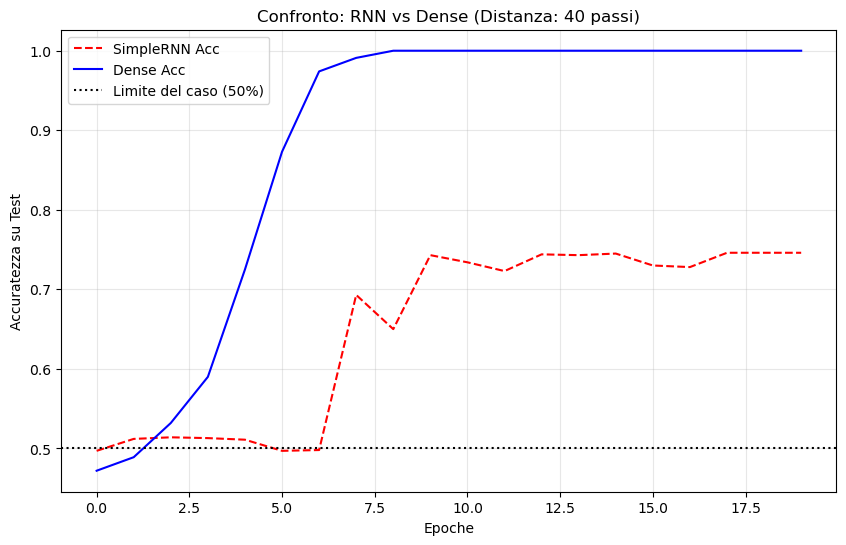


Accuratezza Finale RNN: 0.7460
Accuratezza Finale Dense: 1.0000


In [1]:
"""
AI Overview
Documenti di esercizi di Deep Learning/AI che spaziano da TensorFlow a PyTorch su vari dataset come CIFAR-10 e MNIST.
"""
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# =================================================================
# 1. GENERAZIONE DEL DATASET (The "Second vs Last" Task)
# =================================================================
def generate_logical_data(n_samples, seq_len):
    # Generiamo bit casuali (0 o 1)
    X = np.random.randint(0, 2, size=(n_samples, seq_len, 1)).astype('float32')
    
    # LOGICA: y = 1 se il secondo bit (indice 1) == ultimo bit (indice -1)
    # Usiamo il confronto element-wise e convertiamo il booleano in float
    y = (X[:, 1, 0] == X[:, -1, 0]).astype('float32')
    
    return X, y

# Configurazione
SEQ_LEN = 40
N_SAMPLES = 5000

X_train, y_train = generate_logical_data(N_SAMPLES, SEQ_LEN)
X_test, y_test = generate_logical_data(1000, SEQ_LEN)

# =================================================================
# 2. MODELLO 1: SimpleRNN
# =================================================================
# La RNN deve "leggere" il secondo bit, tenerlo in memoria mentre legge 
# altri 38 bit inutili, e poi confrontarlo con l'ultimo.
rnn_model = models.Sequential([
    layers.Input(shape=(SEQ_LEN, 1)),
    layers.SimpleRNN(32, activation='tanh'),
    layers.Dense(1, activation='sigmoid')
])

rnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("\n--- Training SimpleRNN ---")
rnn_history = rnn_model.fit(X_train, y_train, epochs=20, batch_size=64, 
                            validation_data=(X_test, y_test), verbose=0)

# =================================================================
# 3. MODELLO 2: Dense (MLP) con Flatten
# =================================================================
# Il modello Dense "appiattisce" la sequenza. Vede i 40 bit tutti insieme.
# Ha un collegamento diretto (sinapsi) sia col secondo che con l'ultimo bit.
dense_model = models.Sequential([
    layers.Input(shape=(SEQ_LEN, 1)),
    layers.Flatten(),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

dense_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("--- Training Dense Model ---")
dense_history = dense_model.fit(X_train, y_train, epochs=20, batch_size=64, 
                                validation_data=(X_test, y_test), verbose=0)

# =================================================================
# 4. CONFRONTO RISULTATI
# =================================================================
plt.figure(figsize=(10, 6))
plt.plot(rnn_history.history['val_accuracy'], label='SimpleRNN Acc', color='red', linestyle='--')
plt.plot(dense_history.history['val_accuracy'], label='Dense Acc', color='blue')
plt.axhline(y=0.5, color='black', linestyle=':', label='Limite del caso (50%)')

plt.title(f"Confronto: RNN vs Dense (Distanza: {SEQ_LEN} passi)")
plt.xlabel("Epoche")
plt.ylabel("Accuratezza su Test")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nAccuratezza Finale RNN: {rnn_history.history['val_accuracy'][-1]:.4f}")
print(f"Accuratezza Finale Dense: {dense_history.history['val_accuracy'][-1]:.4f}")